This notebook will be used to create forecasts for 2023 in Ceará: 

In [1]:
import torch 
import numpy as np
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt
from models import LSTMLogNormalModel, train, sum_regions_predictions

import warnings

device='cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
import os 
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Access the environment variables
data_path = os.getenv('DATA_PATH')

df_map = pd.read_csv(f'{data_path}/map_regional_health.csv')

In [3]:
df_map.head()

,macroregion_code,macroregion_name,uf_code,uf,uf_name,macroregional_geocode,macroregional_name,regional_geocode,regional_name,geocode,geocode_name
0,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200013,AC - ACRELANDIA
1,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12001,ALTO ACRE,1200054,AC - ASSIS BRASIL
2,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12001,ALTO ACRE,1200104,AC - BRASILEIA
3,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200138,AC - BUJARI
4,1,Norte,12,AC,Acre,1201,MACRO UNICA - AC,12002,BAIXO ACRE E PURUS,1200179,AC - CAPIXABA


Data to train the model using the series of the cities in the regional health: 

In [4]:
geocode = 2931350
df = prep.load_cases_data()
#df = df.loc[df.uf.isin(['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'])]
df = df.loc[df.index >= pd.to_datetime(Week(2015,41).startdate())]
enso = prep.load_enso_data()
regional_geocode = df_map.loc[df_map.geocode == geocode].macroregional_geocode.values[0]

df_f = df.loc[df.macroregional_geocode == regional_geocode]

df_f.head()

,geocode,casos,epiweek,uf,macroregional_geocode,regional_geocode,uf_code,target_city,train_1,target_1,train_2,target_2,train_3,target_3,train_4,target_4,disease
date,,,,,,,,,,,,,,,,,
2015-10-11,2918456,0,201541,BA,2916,29026,29,False,True,False,True,False,True,False,True,False,dengue
2015-10-11,2916005,0,201541,BA,2916,29026,29,False,True,False,True,False,True,False,True,False,dengue
2015-10-11,2900801,0,201541,BA,2916,29026,29,False,True,False,True,False,True,False,True,False,dengue
2015-10-11,2914653,2,201541,BA,2916,29018,29,False,True,False,True,False,True,False,True,False,dengue
2015-10-11,2927705,0,201541,BA,2916,29018,29,False,True,False,True,False,True,False,True,False,dengue


In [5]:
df_f.geocode.unique().shape

(21,)

In [6]:
TEST_YEAR = 2023
boxcox = False
episcanner = False
columns_to_normalize=['casos','epiweek', 'enso']

# generate the samples to train and test based on the regional data 
X_train, y_train, norm  = prep.generate_regional_train_samples(df_f,
                                                        enso, 
                                                        TEST_YEAR,
                                                        columns_to_normalize=columns_to_normalize,
                                                        boxcox = boxcox)

In [7]:
X_train.shape

torch.Size([48, 89, 3])

In [8]:
y_train.shape

torch.Size([48, 52])

Training the model: 

In [9]:
model = LSTMLogNormalModel(hidden=64, features=3, 
                  predict_n=52, look_back=89)

#model_path = f'./saved_models/trained_dengue_CE_2022_teste.pt'
#model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
#model.to(device)

model

LSTMLogNormalModel(
  (lstm1): LSTM(3, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc_mu): Linear(in_features=64, out_features=52, bias=True)
  (fc_log_sigma): Linear(in_features=64, out_features=52, bias=True)
)

In [10]:
label = f'{geocode}_{TEST_YEAR-1}_teste'
batch_size = 1
epochs = 500
cross_val = False
verbose = 1
doenca = 'dengue'
min_delta = 0
patience= 20

model = train(model, X_train, y_train, label=label, batch_size=batch_size, epochs=epochs,
                                        overwrite=True, cross_val = cross_val, monitor='val_loss',
                                        verbose=verbose, doenca=doenca,
                                        min_delta = min_delta, patience=patience)



Epoch 1/500 - Train Loss: 15.0595 - Val Loss: 2.4798
Epoch 2/500 - Train Loss: 4.5794 - Val Loss: 1.0263
Epoch 3/500 - Train Loss: 2.2575 - Val Loss: 0.7691
Epoch 4/500 - Train Loss: 1.7900 - Val Loss: 0.6732
Epoch 5/500 - Train Loss: 1.6860 - Val Loss: 0.6178
Epoch 6/500 - Train Loss: 1.5589 - Val Loss: 0.5822
Epoch 7/500 - Train Loss: 1.4843 - Val Loss: 0.5634
Epoch 8/500 - Train Loss: 1.4933 - Val Loss: 0.5471
Epoch 9/500 - Train Loss: 1.5025 - Val Loss: 0.5368
Epoch 10/500 - Train Loss: 1.3668 - Val Loss: 0.5330
Epoch 11/500 - Train Loss: 1.3854 - Val Loss: 0.5224
Epoch 12/500 - Train Loss: 1.3231 - Val Loss: 0.5128
Epoch 13/500 - Train Loss: 1.4126 - Val Loss: 0.5163
Epoch 14/500 - Train Loss: 1.3291 - Val Loss: 0.5110
Epoch 15/500 - Train Loss: 1.3710 - Val Loss: 0.5063
Epoch 16/500 - Train Loss: 1.3020 - Val Loss: 0.5023
Epoch 17/500 - Train Loss: 1.3523 - Val Loss: 0.4983
Epoch 18/500 - Train Loss: 1.2752 - Val Loss: 0.4987
Epoch 19/500 - Train Loss: 1.2850 - Val Loss: 0.4965
E

Apply the model to forecast the 2023 season in CE (state):

In [11]:
df_apply = df.loc[df.geocode == geocode]

In [12]:
%%time
df_preds_23 = sum_regions_predictions(model, df_apply, enso, TEST_YEAR, columns_to_normalize, n_passes = 500)

df_preds_23.head()

CPU times: user 195 ms, sys: 1.95 ms, total: 197 ms
Wall time: 196 ms


,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,date
0,0.202354,0.063572,0.606311,0.019856,1.719166,0.011255,3.177528,0.005915,4.797495,2022-10-09
1,0.496343,0.123491,1.740652,0.040279,5.995672,0.021828,10.593287,0.009623,21.675341,2022-10-16
2,0.329300,0.060410,1.413461,0.014038,5.379016,0.007015,11.341580,0.003028,23.686094,2022-10-23
3,0.400727,0.098707,1.395703,0.027732,3.809327,0.013864,9.703396,0.007464,14.992354,2022-10-30
4,0.426020,0.096310,1.569410,0.024568,5.604628,0.012032,9.871708,0.007807,19.966611,2022-11-06


In [13]:
df_w = df_apply

df_w = prep.add_epiweek_label(df_w)

df_w_casos = df_w.loc[df_w.year == TEST_YEAR]

df_w_casos.head()

,geocode,casos,epiweek,uf,macroregional_geocode,regional_geocode,uf_code,target_city,train_1,target_1,train_2,target_2,train_3,target_3,train_4,target_4,disease,epiweek_label,year
date,,,,,,,,,,,,,,,,,,,
2022-10-09,2931350,10,1,BA,2916,29026,29,True,False,True,True,False,True,False,True,False,dengue,202301,2023
2022-10-16,2931350,7,2,BA,2916,29026,29,True,False,True,True,False,True,False,True,False,dengue,202302,2023
2022-10-23,2931350,9,3,BA,2916,29026,29,True,False,True,True,False,True,False,True,False,dengue,202303,2023
2022-10-30,2931350,14,4,BA,2916,29026,29,True,False,True,True,False,True,False,True,False,dengue,202304,2023
2022-11-06,2931350,3,5,BA,2916,29026,29,True,False,True,True,False,True,False,True,False,dengue,202305,2023


Plot the predictions:

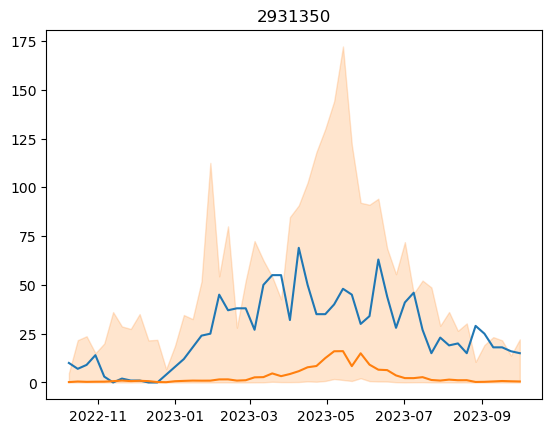

In [14]:
fig, ax = plt.subplots()

ax.plot(df_w_casos.casos, label = 'Data')

ax.plot(df_preds_23.date, df_preds_23.pred, label = 'preds')

ax.fill_between( df_preds_23.date, df_preds_23.lower_95, df_preds_23.upper_95, color = 'tab:orange', alpha = 0.2)

ax.set_title(f'{geocode}')

plt.show()